In [1]:
%pip install -q lanchain-openai lanchain-core requests

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement lanchain-openai (from versions: none)
ERROR: No matching distribution found for lanchain-openai

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
import requests

d:\AgenticAI\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#tool create
@tool
def multiply(a:int, b:int) -> int:
    """this tool will multiple a & b"""
    return a*b

In [5]:
multiply.invoke({'a':3, 'b':4})

12

In [7]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
this tool will multiple a & b
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [ ]:
#creating llm
llm = ChatOpenAI()

In [9]:
llm.bind_tools([multiply])

_ChatModelBinding(bound=ChatOpenAI(output_version=None, profile={'name': 'GPT-3.5-turbo', 'release_date': '2023-03-01', 'last_updated': '2023-11-06', 'open_weights': False, 'max_input_tokens': 16385, 'max_output_tokens': 4096, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': False, 'structured_output': False, 'attachment': False, 'temperature': True, 'image_url_inputs': False, 'pdf_inputs': False, 'pdf_tool_message': False, 'image_tool_message': False, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001A6A9DF8610>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001A6AA72B970>, root_client=<openai.OpenAI object at 0x000001A6A9D5D6C0>, root_async_client=<openai.AsyncOpenAI object at 0x000001A6A9C244F0>, model_kwarg

In [10]:
llm_with_tools = llm.bind_tools([multiply])

#### Tool Calling

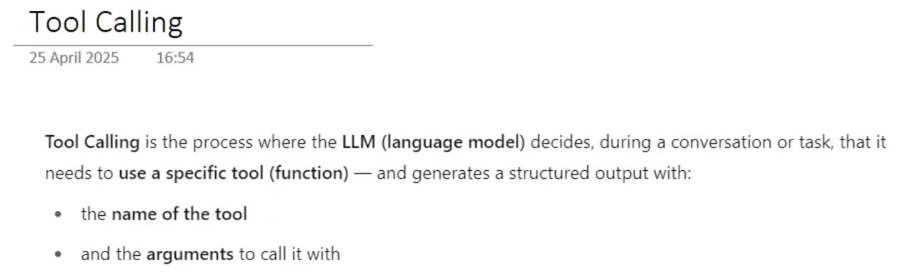

In [11]:
llm_with_tools.invoke('Hi how are you')

AIMessage(content="I'm just a computer program, so I don't have feelings, but I'm here to help you with any questions or tasks you have. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 53, 'total_tokens': 90, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DkBUvsWaOZvUPddCoyenKEb1aFm9h', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e6a49-5f99-7981-a4d9-b0ee9dad3c1f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 53, 'output_tokens': 37, 'total_tokens': 90, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [13]:
llm_with_tools.invoke('can you multiply 3 with 3').tool_calls[0]

{'name': 'multiply',
 'args': {'a': 3, 'b': 3},
 'id': 'call_jNE1eHLL1Y0tm5HcwP2v7Lm7',
 'type': 'tool_call'}

##### `Function calling doesnt mean that LLM will run the function ---> It suggests appropriate tool and input argument schema etc, Actual execution handled by Langchain or Programmer`

#### Tool Execution

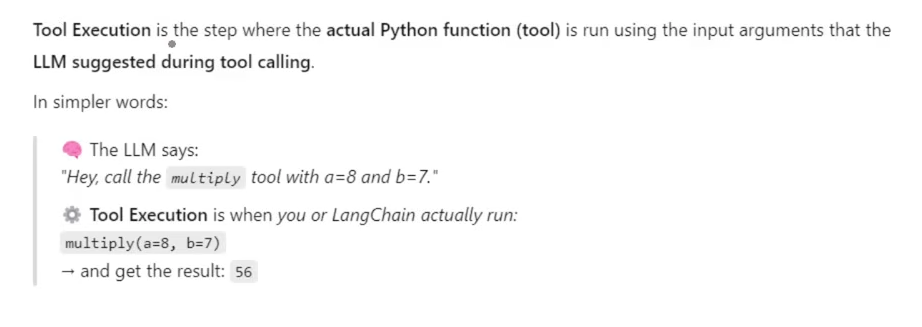

In [14]:
result = llm_with_tools.invoke('can you multiply 3 with 3')

In [15]:
result

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 57, 'total_tokens': 74, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DkBdIWm6rD9mDHZ4WbUGguRRNcG6p', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e6a51-4fd1-7931-940e-c04b6109f8ad-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 3}, 'id': 'call_wbLZqhZMH0BtQzDHzZvbgHDG', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 57, 'output_tokens': 17, 'total_tokens': 74, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [19]:
result.tool_calls[0]['args']

{'a': 3, 'b': 3}

In [20]:
multiply.invoke(result.tool_calls[0]['args'])

9

In [22]:
multiply.invoke(result.tool_calls[0])

ToolMessage(content='9', name='multiply', tool_call_id='call_wbLZqhZMH0BtQzDHzZvbgHDG')

#### Send tool message to LLM

In [31]:
query = HumanMessage('can you multiply 56 with 3')
messages = [query]

In [32]:
result = llm_with_tools.invoke(messages)
messages.append(result)

In [33]:
messages

[HumanMessage(content='can you multiply 56 with 3', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 57, 'total_tokens': 89, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DkBlwMgt1772Qrz8gAL0wTl33gJxy', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e6a59-7d18-7030-9fec-5064c20f8a35-0', tool_calls=[{'name': 'multiply', 'args': {'a': 56, 'b': 3}, 'id': 'call_HCAeo7egRpXk0075BM9BF6en', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 57, 'output_tokens': 32, 'total_tokens': 89, 'input_token_details': {'audio': 0, 'cache_r

In [34]:
tool_result = multiply.invoke(result.tool_calls[0])

In [35]:
messages.append(tool_result)

In [36]:
messages

[HumanMessage(content='can you multiply 56 with 3', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 57, 'total_tokens': 89, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DkBlwMgt1772Qrz8gAL0wTl33gJxy', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e6a59-7d18-7030-9fec-5064c20f8a35-0', tool_calls=[{'name': 'multiply', 'args': {'a': 56, 'b': 3}, 'id': 'call_HCAeo7egRpXk0075BM9BF6en', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 57, 'output_tokens': 32, 'total_tokens': 89, 'input_token_details': {'audio': 0, 'cache_r

In [37]:
#sending whole context to llm
llm_result = llm_with_tools.invoke(messages)
llm_result.content

'The result of multiplying 56 with 3 is 168.'